In [17]:
%pip install torch opencv-python matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


In [18]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import cv2

# load image
img = cv2.imread("image.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = torch.tensor(img, dtype=torch.float32) / 255.0
img = img.permute(2, 0, 1)
img = img.unsqueeze(0)#.unsqueeze(0)  # (1,1,H,W)

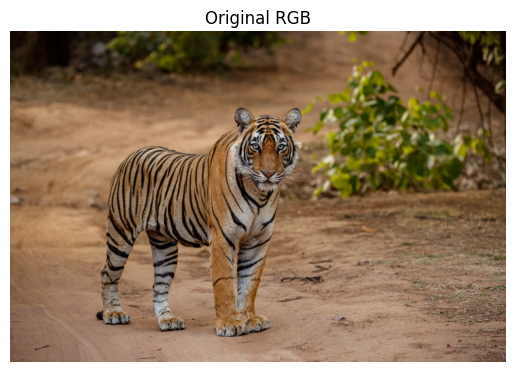

In [19]:
plt.imshow(img[0].permute(1, 2, 0))
plt.title("Original RGB")
plt.axis('off')
plt.show()

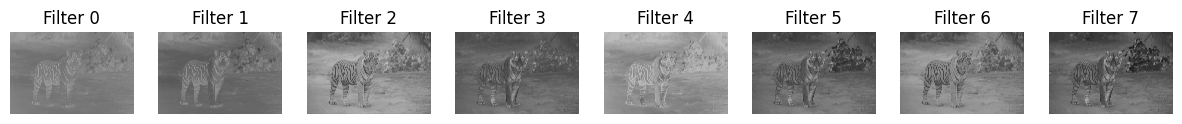

In [20]:


# random CNN layer
conv = nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3, padding=1)

# forward pass
with torch.no_grad():
    output = conv(img)  # (1,8,H,W)

# visualize all feature maps
fig, axes = plt.subplots(1, 8, figsize=(15,3))

for i in range(8):
    axes[i].imshow(output[0,i], cmap='gray')
    axes[i].set_title(f"Filter {i}")
    axes[i].axis('off')

plt.show()

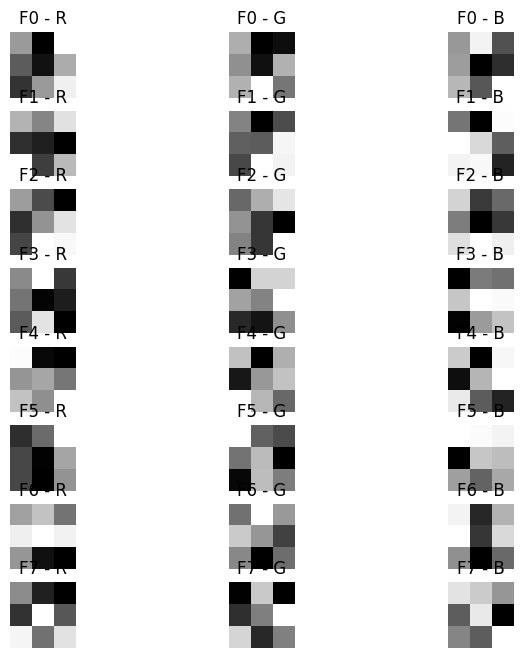

In [21]:
weights = conv.weight.data

# visualize
fig, axes = plt.subplots(8, 3, figsize=(8, 8))

for i in range(8):  # 8 filters
    for j in range(3):  # R, G, B
        axes[i, j].imshow(weights[i, j], cmap='gray')
        axes[i, j].set_title(f"F{i} - {'RGB'[j]}")
        axes[i, j].axis('off')